# National province score maps (DDPM climate impacts | 2560–2567)

Purpose: presentation-ready **province-level** maps using **min–max normalization**:

`score = (x - min) / (max - min)`

where min/max are computed nationally across provinces (per metric).

This notebook mirrors the structure and plotting style from
[`ddpm_national_tambon_impact_2560_2567.ipynb`](ψ/incubate/DCCE/CRI/data_system/script/analysis_notebooks/ddpm_national_tambon_impact_2560_2567.ipynb:1)
but computes scores at **province level**.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# Thai text rendering (Windows): force a Thai-capable font
# NOTE: If you see □□□□ in titles/labels, install a Thai font and set it here.
plt.rcParams['font.family'] = 'Tahoma'
plt.rcParams['axes.unicode_minus'] = False

# Base path = repo data_system folder (robust to notebook cwd)
# Walk upward until we find a folder named 'data_system'.
BASE_PATH = Path.cwd().resolve()
_p = BASE_PATH
while _p.name != 'data_system' and _p.parent != _p:
    _p = _p.parent
if _p.name != 'data_system':
    raise RuntimeError(f'Cannot locate data_system root from cwd: {Path.cwd().resolve()}')
BASE_PATH = _p


FACT_PATH = BASE_PATH / 'data/2_gold/ddpm/fact_ddpm_tambon_impact_climate_2560_2567.csv'
PROV_SHP_PATH = BASE_PATH / 'data/1_silver/dopa/province_boundaries_enriched.shp'
OUT_DIR = BASE_PATH / 'output/national/province_score_maps'

METRICS = ['affected_households_sum', 'affected_people_sum', 'deaths_sum']

print('FACT_PATH:', FACT_PATH)
print('PROV_SHP_PATH:', PROV_SHP_PATH)
print('OUT_DIR:', OUT_DIR)


FACT_PATH: C:\Users\sitth\OracleWorkspace\Arun_Creagy\ψ\incubate\DCCE\CRI\data_system\data\2_gold\ddpm\fact_ddpm_tambon_impact_climate_2560_2567.csv
PROV_SHP_PATH: C:\Users\sitth\OracleWorkspace\Arun_Creagy\ψ\incubate\DCCE\CRI\data_system\data\1_silver\dopa\province_boundaries_enriched.shp
OUT_DIR: C:\Users\sitth\OracleWorkspace\Arun_Creagy\ψ\incubate\DCCE\CRI\data_system\output\national\province_score_maps


In [2]:
def _read_csv_flex(path: Path) -> pd.DataFrame:
    try:
        return pd.read_csv(path, encoding='utf-8')
    except UnicodeDecodeError:
        return pd.read_csv(path, encoding='cp874')

def _clean_code_6(series: pd.Series) -> pd.Series:
    s = series.astype(str).str.extract(r'(\d+)')[0].fillna('')
    return s.str[-6:].str.zfill(6)

def _clean_code_2(series: pd.Series) -> pd.Series:
    s = series.astype(str).str.extract(r'(\d+)')[0].fillna('')
    return s.str[-2:].str.zfill(2)

def minmax_score(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors='coerce').fillna(0.0).astype(float)
    mn = float(s.min()) if len(s) else 0.0
    mx = float(s.max()) if len(s) else 0.0
    denom = mx - mn
    if denom <= 0:
        return pd.Series(np.zeros(len(s)), index=s.index, dtype=float)
    return (s - mn) / denom


## 1) Load data
- Gold fact table is tambon-level, but includes `subdistrict_code` (6-digit).
- Province code is derived as the first 2 digits of subdistrict code.
- Province geometry is the Silver enriched layer with `prov_code`.

In [3]:
fact = _read_csv_flex(FACT_PATH)
gdf_prov = gpd.read_file(PROV_SHP_PATH)

print('fact.shape =', fact.shape)
print('gdf_prov.shape =', gdf_prov.shape)
print('fact.columns sample =', list(fact.columns)[:20])
print('gdf_prov.columns =', list(gdf_prov.columns))


fact.shape = (6967, 13)
gdf_prov.shape = (77, 5)
fact.columns sample = ['subdistrict_code', 'province_code', 'affected_households_sum', 'affected_people_sum', 'deaths_sum', 'avg_yoy_change', 'province_name_th', 'district_name_th', 'subdistrict_name_th', 'pct_national_affected_households_sum', 'pct_national_affected_people_sum', 'pct_national_deaths_sum', 'pct_national_avg_yoy_change']
gdf_prov.columns = ['P_NAME_T', 'P_NAME_E', 'Area_km2', 'prov_code', 'geometry']


## 2) Province aggregation + min–max scoring
Aggregate tambon facts to province totals, then min–max normalize across provinces nationally (per metric).

In [4]:
if 'subdistrict_code' not in fact.columns:
    raise KeyError('Missing subdistrict_code in fact')

fact = fact.copy()
fact['subdistrict_code'] = _clean_code_6(fact['subdistrict_code'])
fact = fact.loc[fact['subdistrict_code'].ne('')].copy()
fact['province_code'] = fact['subdistrict_code'].str[:2]

for m in METRICS:
    if m not in fact.columns:
        raise KeyError(f'Missing metric in fact: {m}')
    fact[m] = pd.to_numeric(fact[m], errors='coerce').fillna(0.0)

prov_stats = (
    fact.groupby('province_code', as_index=False)[METRICS]
        .sum(numeric_only=True)
)
prov_stats['province_code'] = _clean_code_2(prov_stats['province_code'])

for m in METRICS:
    prov_stats[f'score_{m}'] = minmax_score(prov_stats[m])

display(prov_stats.sort_values(f'score_{METRICS[0]}', ascending=False).head(10))


,province_code,affected_households_sum,affected_people_sum,deaths_sum,score_affected_households_sum,score_affected_people_sum,score_deaths_sum
38,50,506865.0,299860.0,19.0,1.000000,1.000000,0.791667
63,80,214024.0,28978.0,21.0,0.421863,0.096638,0.875000
76,96,149279.0,231749.0,7.0,0.294041,0.772857,0.291667
45,57,130760.0,40012.0,10.0,0.257480,0.133436,0.416667
34,46,85089.0,133300.0,4.0,0.167315,0.444541,0.166667
67,84,73264.0,37999.0,18.0,0.143969,0.126722,0.750000
51,64,61566.0,68624.0,4.0,0.120875,0.228853,0.166667
74,94,52748.0,42575.0,24.0,0.103466,0.141983,1.000000
40,52,50475.0,9218.0,7.0,0.098978,0.030741,0.291667
18,30,47464.0,23233.0,4.0,0.093034,0.077479,0.166667


## 3) Join to province boundaries (Silver enriched)
We join on `province_code` (2-digit) derived from `prov_code`.

In [5]:
if gdf_prov.crs is None or gdf_prov.crs.to_epsg() != 4326:
    gdf_prov = gdf_prov.to_crs(epsg=4326)

if 'prov_code' not in gdf_prov.columns:
    raise KeyError('Province geometry missing prov_code. Columns: ' + str(list(gdf_prov.columns)))

gdf_prov = gdf_prov.copy()
gdf_prov['province_code'] = _clean_code_2(gdf_prov['prov_code'])

prov_map = gdf_prov.merge(prov_stats, on='province_code', how='left')
for m in METRICS:
    prov_map[f'score_{m}'] = pd.to_numeric(prov_map[f'score_{m}'], errors='coerce').fillna(0.0)

print('prov_map.shape =', prov_map.shape)
print('missing any score rows =', int((prov_map[[f'score_{m}' for m in METRICS]].isna().any(axis=1)).sum()))


prov_map.shape = (77, 12)
missing any score rows = 0


## 4) National province choropleths (one map per metric)
Static maps (GeoPandas + Matplotlib) with values in [0,1].

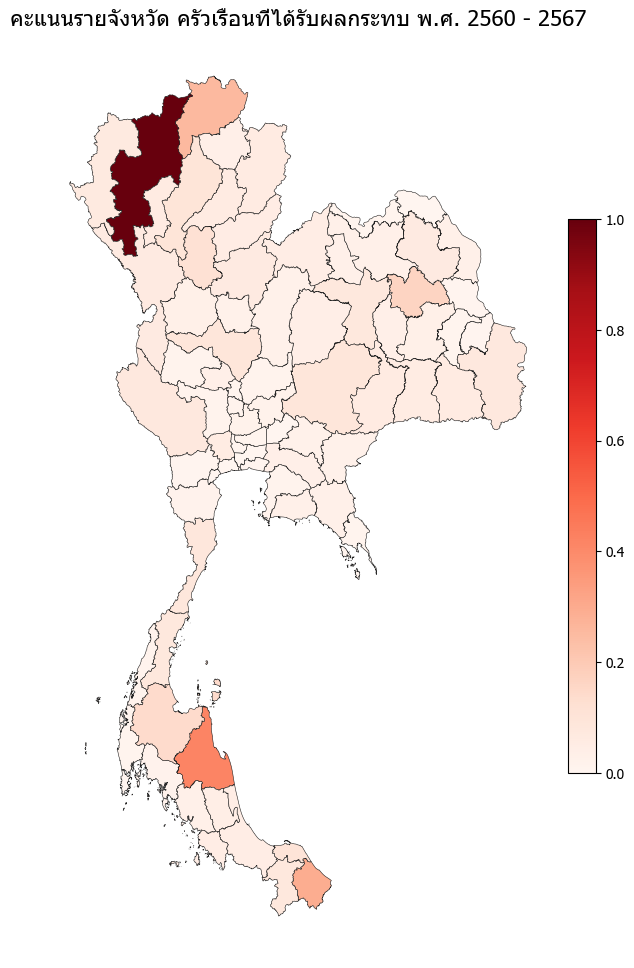

Saved: C:\Users\sitth\OracleWorkspace\Arun_Creagy\ψ\incubate\DCCE\CRI\data_system\output\national\province_score_maps\คะแนนรายจังหวัด ครัวเรือนที่ได้รับผลกระทบ พ.ศ. 2560 - 2567.png


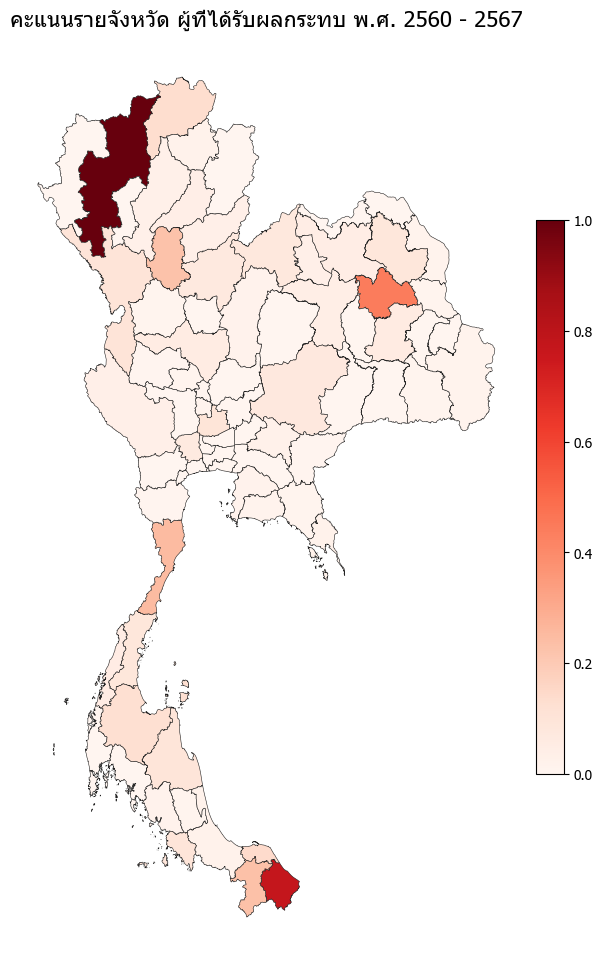

Saved: C:\Users\sitth\OracleWorkspace\Arun_Creagy\ψ\incubate\DCCE\CRI\data_system\output\national\province_score_maps\คะแนนรายจังหวัด ผู้ที่ได้รับผลกระทบ พ.ศ. 2560 - 2567.png


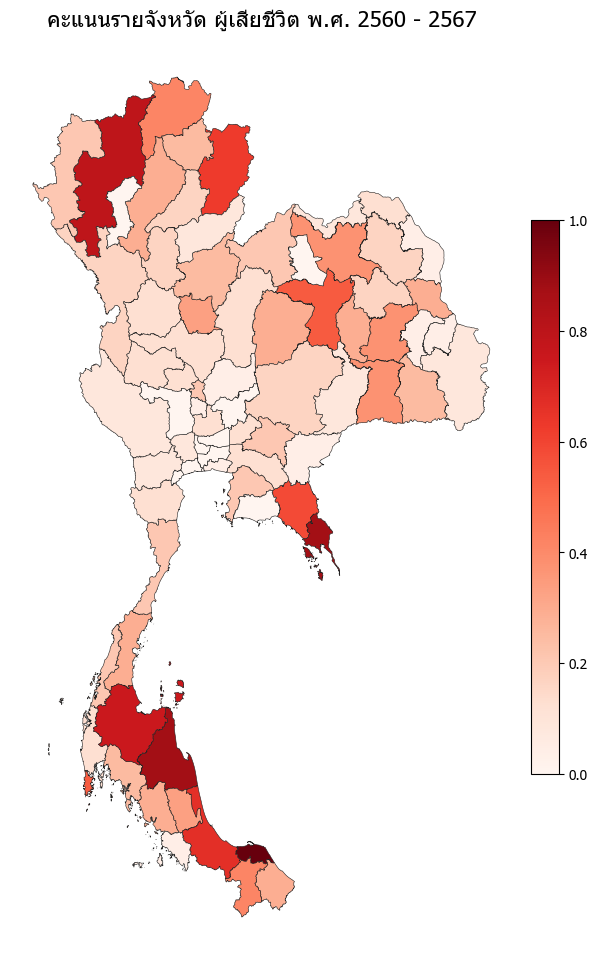

Saved: C:\Users\sitth\OracleWorkspace\Arun_Creagy\ψ\incubate\DCCE\CRI\data_system\output\national\province_score_maps\คะแนนรายจังหวัด ผู้เสียชีวิต พ.ศ. 2560 - 2567.png


In [6]:
fname = [ "คะแนนรายจังหวัด ครัวเรือนที่ได้รับผลกระทบ พ.ศ. 2560 - 2567",
         "คะแนนรายจังหวัด ผู้ที่ได้รับผลกระทบ พ.ศ. 2560 - 2567",
         "คะแนนรายจังหวัด ผู้เสียชีวิต พ.ศ. 2560 - 2567"


        ]   

def plot_province_score(gdf: gpd.GeoDataFrame, score_col: str, title: str, out_png: Path, *, cmap: str = 'Reds') -> None:
    fig, ax = plt.subplots(1, 1, figsize=(12, 12))
    ax.set_title(title, fontsize=16)
    ax.set_axis_off()

    gdf.plot(
        column=score_col,
        ax=ax,
        cmap=cmap,
        legend=True,
        legend_kwds={'shrink': 0.6, 'fraction': 0.04, 'pad': 0.02},
        linewidth=0.4,
        edgecolor='#222222',
        vmin=0,
        vmax=1,
        missing_kwds={'color': '#f0f0f0', 'edgecolor': 'none', 'label': 'No data'},
    )

    # Show inside notebook
    plt.show()

    # Save PNG
    fig.tight_layout()
    out_png.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_png, dpi=200)
    plt.close(fig)

titles = {
    'affected_households_sum': 'คะแนนจังหวัด (Min–Max) : ครัวเรือนที่ได้รับผลกระทบ พ.ศ. 2560–2567',
    'affected_people_sum': 'คะแนนจังหวัด (Min–Max) : ผู้ที่ได้รับผลกระทบ พ.ศ. 2560–2567',
    'deaths_sum': 'คะแนนจังหวัด (Min–Max) : จำนวนผู้เสียชีวิต พ.ศ. 2560–2567',
}
i = 0
for m in METRICS:
    saved_name = fname[i] +".png"
    out_png = OUT_DIR / saved_name
    plot_province_score(prov_map, f'score_{m}', fname[i], out_png, cmap='Reds')
    print('Saved:', out_png)
    i = i+1
